# Forecasting quick start

This notebook uses ERA5 data and a pretrained NeuralGCM model to make a
weather forecast with **neuralgcm-torch**, the idiomatic-PyTorch
rewrite of NeuralGCM (plain `nn.Module`s; no JAX, gin or haiku at runtime).

The forecast is made in 3 steps:
1. A slice of ERA5 data is regridded to model resolution
2. The NeuralGCM model state is initialized and rolled out
3. Predictions and reference trajectory are combined for visualization

This mirrors the upstream
[inference_demo](https://github.com/neuralgcm/neuralgcm/blob/main/docs/inference_demo.ipynb)
notebook. It needs network access for the model checkpoint and the ERA5
data (both anonymous GCS); a CUDA GPU is recommended but not required.

In [2]:
import pathlib

import numpy as np
import torch
import xarray

from dinosaur_torch import horizontal_interpolation
from dinosaur_torch import xarray_utils
import neuralgcm_torch as neuralgcm

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Load a pre-trained NeuralGCM model

By default, this notebook uses the 2.8° deterministic NeuralGCM model.

`neuralgcm-torch` runs *converted* checkpoints: the original NeuralGCM
gin-config + haiku-parameter pickles were translated once, offline, into
plain `torch.save` files (see `neuralgcm_torch.checkpoint` for the
format). The cell below fetches one with `pretrained.fetch_checkpoint` —
downloaded from the Hugging Face Hub on first use and cached, or read from
a local `checkpoints/` directory if present.

[Other available checkpoints](https://github.com/neuralgcm/neuralgcm/blob/main/docs/checkpoints.md)
include deterministic 0.7°, 1.4° and stochastic 1.4° NeuralGCM variations.
All models are licensed under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).

In [3]:
model_name = 'deterministic_2_8_deg'  #@param ['deterministic_0_7_deg', 'deterministic_1_4_deg', 'deterministic_2_8_deg', 'stochastic_1_4_deg']

from neuralgcm_torch import pretrained
# Fetched from the Hugging Face Hub on first use (cached), or reused from
# a local checkpoints/ directory if present.
converted_path = pretrained.fetch_checkpoint(model_name, local_root='checkpoints')
model = neuralgcm.PressureLevelModel.from_checkpoint(converted_path, device=device)

## Load ERA5 data from GCP/Zarr

Select out a few days of data from ERA5:

In [4]:
era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
full_era5 = xarray.open_zarr(
    era5_path, chunks=None, storage_options=dict(token='anon')
)

demo_start_time = '2020-02-14'
demo_end_time = '2020-02-18'
data_inner_steps = 24  # process every 24th hour

sliced_era5 = (
    full_era5
    [model.input_variables + model.forcing_variables]
    .pipe(
        xarray_utils.selective_temporal_shift,
        variables=model.forcing_variables,
        time_shift='24 hours',
    )
    .sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
    .compute()
)

Regrid to NeuralGCM's native resolution:

In [5]:
era5_grid = xarray_utils.grid_spec_from_dataset(full_era5)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_grid, skipna=True, device=device
)
eval_era5 = xarray_utils.regrid_horizontal(sliced_era5, regridder)
eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)

## Make the forecast

In [6]:
inner_steps = 24  # save model outputs once every 24 hours
outer_steps = 4 * 24 // inner_steps  # total of 4 days
timedelta = np.timedelta64(1, 'h') * inner_steps
times = np.arange(outer_steps) * inner_steps  # time axis in hours

# initialize model state
inputs = model.inputs_from_xarray(eval_era5.isel(time=0))
input_forcings = model.forcings_from_xarray(eval_era5.isel(time=0))
initial_state = model.encode(inputs, input_forcings, rng=42)

# use persistence for forcing variables (SST and sea ice cover)
all_forcings = model.forcings_from_xarray(eval_era5.head(time=1))

# make forecast
final_state, predictions = model.unroll(
    initial_state,
    all_forcings,
    steps=outer_steps,
    timedelta=timedelta,
    start_with_input=True,
)
predictions_ds = model.data_to_xarray(predictions, times=times)

For longer rollouts, `model.compile(initial_state, all_forcings)` wraps the
advance step with `torch.compile` first (a one-time cost of a few minutes
that makes each simulated day several times faster).

## Compare forecast to ERA5

See [WeatherBench2](https://sites.research.google/weatherbench/) for more
comprehensive evaluations and archived NeuralGCM forecasts.

In [7]:
# Selecting ERA5 targets from exactly the same time slice
target_trajectory = model.inputs_from_xarray(
    eval_era5
    .thin(time=(inner_steps // data_inner_steps))
    .isel(time=slice(outer_steps))
)
target_data_ds = model.data_to_xarray(target_trajectory, times=times)

combined_ds = xarray.concat([target_data_ds, predictions_ds], 'model')
combined_ds.coords['model'] = ['ERA5', 'NeuralGCM']

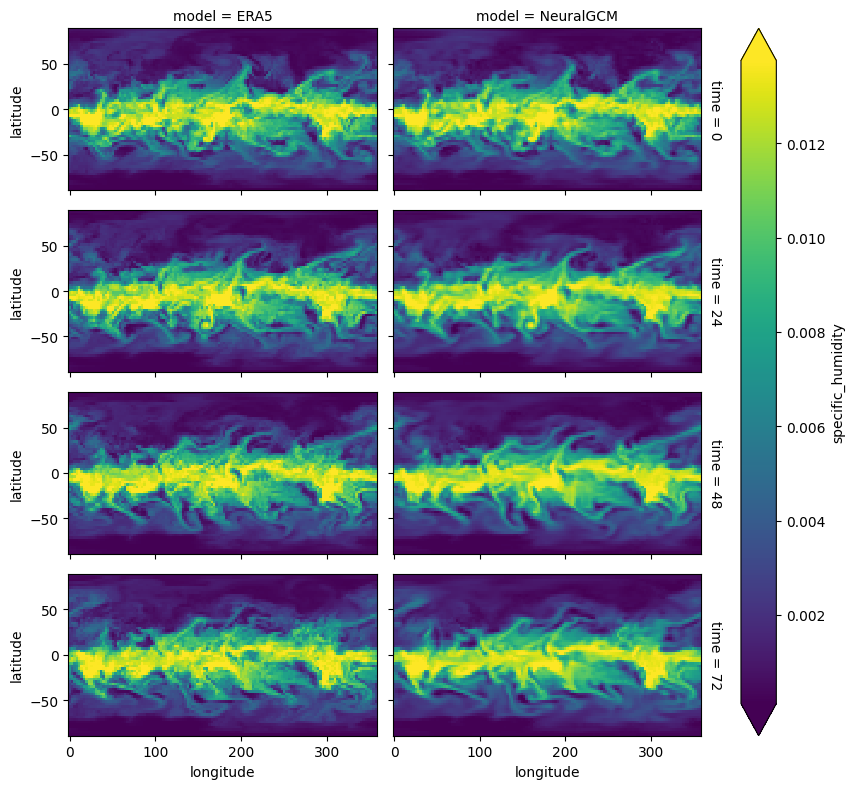

In [8]:
# Visualize ERA5 vs NeuralGCM trajectories
combined_ds.specific_humidity.sel(level=850).plot(
    x='longitude', y='latitude', row='time', col='model', robust=True, aspect=2, size=2
);